In [58]:
import warnings
warnings.filterwarnings("ignore")
from yfinance import download
from numpy import where
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt
from datetime import date
from numpy import nan

# **0.0**
O objetivo principal deste exercício é realizar predições sobre a ocorrência
de aumento do desvio padrão (sd), representado pela classe 1 no modelo.

O alvo é definido a partir do desvio padrão de 21 dias no futuro,
obtido por meio do deslocamento temporal da série (shift),
permitindo comparar a volatilidade futura com a atual.


# **1.0**

*Dados*

In [59]:
ticker = 'klbn4.sa'
start = '2013-01-16'
end = '2023-01-16'

In [60]:
df = download(
    ticker, 
    start=start, 
    end=end,
    interval='1d',
    auto_adjust=False, 
    progress=False).droplevel(1, axis=1).reset_index()

In [61]:
df.tail(3)

Price,Date,Adj Close,Close,High,Low,Open,Volume
2481,2023-01-11,2.880695,3.582358,3.672367,3.537353,3.672367,6184381
2482,2023-01-12,2.895171,3.600360,3.618361,3.555355,3.573357,2483196
2483,2023-01-13,2.909646,3.618361,3.618361,3.546354,3.600360,3394105


---

# **2.0**

*Retorno, Alvo, Desvio padrão*

In [62]:
class PreparacaoDosDados:

    def __init__(self, df):
        self.df = df

    def retorno(self): 
        self.df['ret'] = self.df['Close'].pct_change(1)
    
    def desvio_padrao(self):
        self.df['sd'] = self.df['ret'].rolling(21).std()

    def sd_alvo(self): # --!?
        """
        Se o desvio padrão (sd de 21 dias) no futuro estará acima (1) ou abaixo (0) da desvio padrão atual.
        """
        self.df['sd_alvo'] = self.df['sd'].shift(-21)

    def date_alvo(self):
        self.df['Date_alvo'] = self.df['Date'].shift(-21)

    def var_alvo(self):
        self.df['var_alvo'] = self.df['sd_alvo'] - self.df['sd']
    
    def bin_alvo(self):
        self.df['bin_alvo'] = where(self.df['var_alvo'] > 0, 1, 0)

    def preparar(self):
        self.retorno()
        self.desvio_padrao()
        self.df = self.df.dropna()
        self.sd_alvo()
        self.date_alvo()
        self.var_alvo()
        self.bin_alvo()
        return self.df

In [63]:
preparacao_dos_dados = PreparacaoDosDados(df)
df = preparacao_dos_dados.preparar()

In [64]:
df.iloc[:,7:13].tail(23)

Price,ret,sd,sd_alvo,Date_alvo,var_alvo,bin_alvo
2461,-0.037647,0.020798,0.014306,2023-01-12,-0.006492,0
2462,0.014670,0.021308,0.013929,2023-01-13,-0.007380,0
2463,-0.024096,0.021420,NaN,NaT,NaN,0
2464,0.004938,0.021019,NaN,NaT,NaN,0
2465,-0.029484,0.021649,NaN,NaT,NaN,0
2466,0.010127,0.020997,NaN,NaT,NaN,0
2467,-0.015038,0.020947,NaN,NaT,NaN,0
2468,0.000000,0.020847,NaN,NaT,NaN,0
2469,-0.015267,0.020980,NaN,NaT,NaN,0
2470,-0.007752,0.020419,NaN,NaT,NaN,0


In [65]:
df = df.dropna()

In [66]:
df.iloc[:,7:13].tail(23)

Price,ret,sd,sd_alvo,Date_alvo,var_alvo,bin_alvo
2440,0.051225,0.018213,0.020798,2022-12-13,0.002585,1
2441,-0.004237,0.018188,0.021308,2022-12-14,0.003120,1
2442,-0.021277,0.019193,0.021420,2022-12-15,0.002226,1
2443,-0.026087,0.019427,0.021019,2022-12-16,0.001592,1
2444,-0.013393,0.019826,0.021649,2022-12-19,0.001823,1
2445,-0.031674,0.021287,0.020997,2022-12-20,-0.000291,0
2446,0.009346,0.021333,0.020947,2022-12-21,-0.000386,0
2447,-0.013889,0.021609,0.020847,2022-12-22,-0.000762,0
2448,0.000000,0.021329,0.020980,2022-12-23,-0.000348,0
2449,-0.025822,0.022119,0.020419,2022-12-26,-0.001700,0


In [67]:
fig1 = px.line(df, x=df['Date'], y=["sd", "sd_alvo"], title="Desvio Padrão")
fig1.update_layout(template="plotly_white", hovermode="x unified", height=300)
fig1.show()

In [68]:
class Variaveis:

    def __init__(self, df):
        self.df = df
    
    def variavel_1(self, df):
        self.df['variavel_1'] = (df['sd'] - df['sd'].rolling(8).min()) / (df['sd'].rolling(8).max() - df['sd'].rolling(8).min())
        self.df['variavel_1'] = where(self.df['variavel_1'] <= 0.10, 1, 0)
    
    def variavel_2(self, df):
        self.df['variavel_2'] = (df['Volume'] - df['Volume'].rolling(8).min()) / (df['Volume'].rolling(8).max() - df['Volume'].rolling(9).min())
        self.df['variavel_2'] = where(self.df['variavel_2'] <= 0.10, 1, where(self.df['variavel_2'] >= 0.80, 2, 0))
    
    def variavel_3(self, df):
        self.df['variavel_3'] = (df['sd'].diff() - df['sd'].diff().rolling(8).min()) + (df['sd'].diff() - df['sd'].diff().rolling(8).max())

    def variavel_4(self, df):
        self.df['variavel_4'] = df['sd'] / abs((df['sd'].rolling(21).sum() - df['sd']).rolling(21).sum())
    
    def variavel_5(self, df):
        self.df['variavel_5'] = df['sd'].rolling(5).sum().diff().diff().shift(1) / (1 - df['sd'].diff().diff() * df['Volume'].rolling(5).max())

    # def variavel_6(self, df):
    #     from sklearn.preprocessing import StandardScaler
    #     from sklearn.cluster import KMeans
    #     import numpy as np

    #     # Seleciona a variável
    #     x = self.df[['variavel_4']]

    #     # Máscara para valores válidos
    #     mask = x['variavel_4'].notna()

    #     # Padronização (APENAS dados válidos)
    #     scaler = StandardScaler()
    #     x_scaled = scaler.fit_transform(x.loc[mask])

    #     # K-Means
    #     kmeans = KMeans(
    #         n_clusters=8,
    #         random_state=42,
    #         n_init=10
    #     )

    #     clusters = kmeans.fit_predict(x_scaled)

    #     # Cria coluna com NaN por padrão
    #     self.df['variavel_6'] = np.nan

    #     # Atribui clusters apenas onde há dado válido
    #     self.df.loc[mask, 'variavel_6'] = clusters

    def add(self):
        self.variavel_1(self.df)
        self.variavel_2(self.df)
        self.variavel_3(self.df)
        self.variavel_4(self.df)
        self.variavel_5(self.df)
        # self.variavel_6(self.df)
        return self.df

In [69]:
vars = ['variavel_1', 'variavel_2', 'variavel_3', 'variavel_4', 'variavel_5']

In [70]:
variaveis = Variaveis(df)
df = variaveis.add()

In [71]:
df.iloc[:,13:19].describe()

Price,variavel_1,variavel_2,variavel_3,variavel_4,variavel_5
count,2442.000000,2442.000000,2434.000000,2402.000000,2.435000e+03
mean,0.313677,0.642506,-0.000023,0.002452,4.575133e-06
std,0.464082,0.770436,0.002596,0.000701,1.398955e-04
min,0.000000,0.000000,-0.010743,0.000998,-1.506766e-03
25%,0.000000,0.000000,-0.001333,0.001972,-2.064210e-07
50%,0.000000,0.000000,-0.000079,0.002418,2.213603e-07
75%,1.000000,1.000000,0.001195,0.002825,1.937820e-06
max,1.000000,2.000000,0.010757,0.005484,4.252571e-03


In [72]:
df.iloc[:,13:19].describe()

Price,variavel_1,variavel_2,variavel_3,variavel_4,variavel_5
count,2442.000000,2442.000000,2434.000000,2402.000000,2.435000e+03
mean,0.313677,0.642506,-0.000023,0.002452,4.575133e-06
std,0.464082,0.770436,0.002596,0.000701,1.398955e-04
min,0.000000,0.000000,-0.010743,0.000998,-1.506766e-03
25%,0.000000,0.000000,-0.001333,0.001972,-2.064210e-07
50%,0.000000,0.000000,-0.000079,0.002418,2.213603e-07
75%,1.000000,1.000000,0.001195,0.002825,1.937820e-06
max,1.000000,2.000000,0.010757,0.005484,4.252571e-03


In [73]:
fig = make_subplots(rows=len(vars), cols=1, shared_xaxes=True, vertical_spacing=0.10, subplot_titles=vars)
for row in range(1, len(vars)+1):
    fig.add_trace(go.Scatter(x=df['Date'], y=df[f"variavel_{row}"], mode="lines", name=f"variavel_{row}"), row=row, col=1)
fig.update_layout(template="plotly_white",hovermode="x unified",height=700)
fig.show()

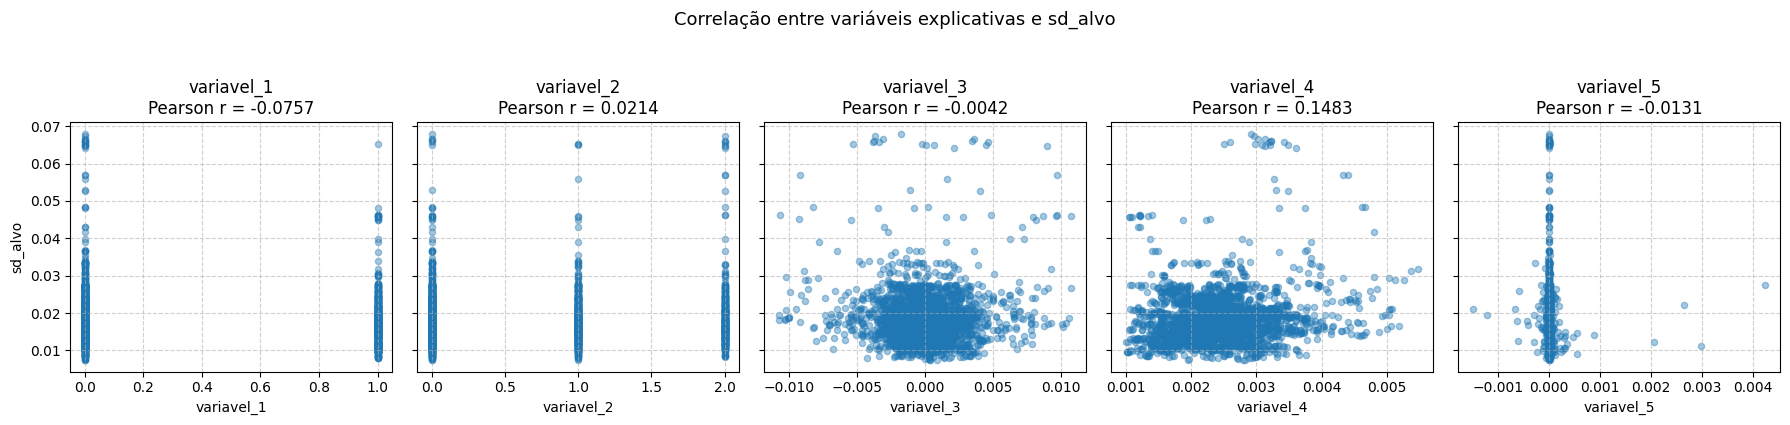

In [74]:
fig, axes = plt.subplots(1, len(vars), figsize=(18, 4), sharey=True)
y = df["sd_alvo"]
for ax, var in zip(axes, vars):
    x = df[var]

    # Scatter
    ax.scatter(x, y, alpha=0.4, s=20)

    # Correlação de Pearson
    corr = x.corr(y)

    # Estética e informação
    ax.set_title(f"{var}\nPearson r = {corr:.4f}")
    ax.set_xlabel(var)
    ax.grid(True, linestyle="--", alpha=0.6)

axes[0].set_ylabel("sd_alvo")

plt.suptitle("Correlação entre variáveis explicativas e sd_alvo", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

In [75]:
df.isnull().sum()

Price
Date           0
Adj Close      0
Close          0
High           0
Low            0
Open           0
Volume         0
ret            0
sd             0
sd_alvo        0
Date_alvo      0
var_alvo       0
bin_alvo       0
variavel_1     0
variavel_2     0
variavel_3     8
variavel_4    40
variavel_5     7
dtype: int64

---

## 2.1

*Variaveis selecionadas*

In [76]:
# vars = ['variavel_1', 'variavel_2', 'variavel_5', 'variavel_6']

# **3.0**

*Treino, Teste*

**Treino**

In [77]:
df_treino = df.iloc[ : int(len(df) / 2)]
df_treino =  df_treino.dropna()

print("Quantidade dados treino:", len(df_treino))

Quantidade dados treino: 1181


In [78]:
x_treino = df_treino[vars]
y_treino = df_treino['bin_alvo']

print("Variáveis selecionadas para o treino:", list(x_treino.columns))

Variáveis selecionadas para o treino: ['variavel_1', 'variavel_2', 'variavel_3', 'variavel_4', 'variavel_5']


In [79]:
x_treino

Price,variavel_1,variavel_2,variavel_3,variavel_4,variavel_5
61,0,2,0.001011,0.002795,-1.240303e-07
62,0,0,0.000241,0.002781,5.261985e-08
63,0,1,-0.001220,0.002740,-2.478471e-07
64,0,1,-0.000970,0.002718,2.059424e-07
65,0,0,-0.000413,0.002690,4.500142e-08
...,...,...,...,...,...
1237,0,2,-0.003494,0.001868,2.590875e-06
1238,0,0,-0.002648,0.001881,-2.375062e-06
1239,0,0,-0.003912,0.001815,1.647051e-06
1240,0,0,-0.003353,0.001784,4.946013e-06


In [80]:
y_treino.tail(3)

1239    0
1240    0
1241    1
Name: bin_alvo, dtype: int64

**Teste**

In [81]:
df_teste = df.iloc[int(len(df) / 2) : ]

print("Quantidade dados teste:", len(df_teste))

Quantidade dados teste: 1221


In [82]:
x_teste = df_teste[vars]
y_teste = df_teste['bin_alvo']

print("Variáveis selecionadas para o teste:", list(x_teste.columns))

Variáveis selecionadas para o teste: ['variavel_1', 'variavel_2', 'variavel_3', 'variavel_4', 'variavel_5']


In [83]:
x_teste

Price,variavel_1,variavel_2,variavel_3,variavel_4,variavel_5
1242,0,0,-0.001351,0.001963,-3.363245e-06
1243,0,0,0.000356,0.002005,9.234149e-06
1244,0,0,-0.000070,0.002016,3.505790e-06
1245,0,2,0.000562,0.002070,-7.848136e-06
1246,0,2,-0.000440,0.002049,3.982144e-06
...,...,...,...,...,...
2458,0,1,-0.002123,0.002866,4.005494e-07
2459,0,1,0.003720,0.003128,1.820829e-07
2460,0,0,-0.001139,0.003082,3.978896e-07
2461,0,2,-0.004518,0.002734,1.415785e-07


In [84]:
y_teste.tail(3)

2460    0
2461    0
2462    0
Name: bin_alvo, dtype: int64

---

# **4.0**

*Modelo e métricas*

## **4.1**

**Treinamento do modelo**

In [85]:
modelo = DecisionTreeClassifier(
    criterion='gini', max_depth=5
    )

modelo.fit(x_treino, y_treino)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
y_pred_treino = modelo.predict(x_treino)
y_pred_teste = modelo.predict(x_teste)

for key, value in {"Treino": y_pred_treino, "Teste": y_pred_teste}.items():
    print(key)
    print(f"Quantidade de '0': {list(value).count(0)}")
    print(f"Quantidade de '1': {list(value).count(1)}\n")

Treino
Quantidade de '0': 328
Quantidade de '1': 853

Teste
Quantidade de '0': 380
Quantidade de '1': 841



## **4.2**

**Matriz de confusão**


| TN
  FP |

| FN 
 TP |

    TN
    Real: Venda | Previsto: Venda
    → Vendas corretamente

    FP
    Real: Venda | Previsto: Compra
    → Compras erradas

    FN
    Real: Compra | Previsto: Venda
    → Vendas erradas
    
    TP
    Real: Compra | Previsto: Compra
    → Compra correta

In [87]:
cm_treino = confusion_matrix(y_treino, y_pred_treino)
cm_teste = confusion_matrix(y_teste, y_pred_teste)

In [88]:
TN_treino = cm_treino[0][0]
FP_treino = cm_treino[0][1]
FN_treino = cm_treino[1][0]
TP_treino = cm_treino[1][1]

TN_teste = cm_teste[0][0]
FP_teste = cm_teste[0][1]
FN_teste = cm_teste[1][0]
TP_teste = cm_teste[1][1]

print("Matriz de confusão - Treino")
print(TN_treino, FP_treino) 
print(FN_treino, TP_treino) 

print("\nMatriz de confusão - Teste")
print(TN_teste, FP_teste) 
print(FN_teste, TP_teste) 


Matriz de confusão - Treino
254 330
74 523

Matriz de confusão - Teste
272 297
108 544


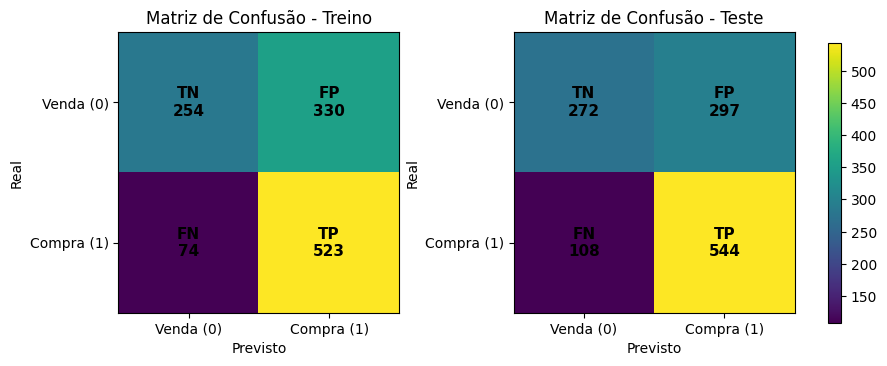

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

labels_quadrantes = {
    (0, 0): "TN",
    (0, 1): "FP",
    (1, 0): "FN",
    (1, 1): "TP",
}

for ax, (key, cm) in zip(axes, {"Treino": cm_treino, "Teste": cm_teste}.items()):
    im = ax.imshow(cm)
    ax.set_title(f"Matriz de Confusão - {key}")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Venda (0)", "Compra (1)"])
    ax.set_yticklabels(["Venda (0)", "Compra (1)"])

    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{labels_quadrantes[(i, j)]}\n{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold"
            )

cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


## **4.3**

*Acurácia*

A acurácia mede a proporção total de decisões corretas do modelo, somando acertos de compra e de venda em relação ao total de previsões. Ela é simples de interpretar, mas pode ser enganosa em problemas financeiros, especialmente quando há muito mais períodos de venda do que de compra, pois o modelo pode parecer bom apenas por acertar muitos “não comprar”. Por isso, a acurácia deve ser usada como uma métrica complementar, nunca isoladamente, sendo mais útil para verificar consistência geral do modelo do que para avaliar risco ou qualidade das decisões de compra.

![img](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi.ibb.co%2F47bHNBb%2FClassification-Image-3.png&f=1&nofb=1&ipt=46eeaaee419b67ca7939f79ca47d4c5acdf1321ff0e280d800373eed886f6397)

In [90]:
acc_treino = accuracy_score(y_treino, y_pred_treino)
acc_teste = accuracy_score(y_teste, y_pred_teste)

print(f'Acurácia treino: {acc_treino:.2%}\nAcurácia teste: {acc_teste:.2%}')

Acurácia treino: 65.79%
Acurácia teste: 66.83%


## **4.4**

*Recall*

Para avaliar o recall, observe que ele mede a capacidade do modelo de capturar todas as oportunidades reais de compra, indicando a proporção de compras corretas que o modelo conseguiu identificar. Um recall alto significa que o modelo perde poucas oportunidades (FN baixo), enquanto um recall baixo indica que muitas boas compras estão sendo ignoradas. Em finanças, o recall está diretamente ligado à agressividade da estratégia: aumentar o recall tende a gerar mais operações, mas pode elevar o risco se não vier acompanhado de um bom precision. Por isso, o recall deve ser analisado em conjunto com precision e com a matriz de confusão, para entender se o ganho em oportunidades não está sendo obtido à custa de erros excessivos.

![img](https://i.ibb.co/7WhtF7y/Classification-Image-4.png)

**Treino**

In [91]:
recall_treino_0 = TN_treino / (TN_treino + FP_treino)
print(f'recall [0, venda]: {recall_treino_0:.2%}')

recall [0, venda]: 43.49%


In [92]:
recall_treino_1 = TP_treino / (TP_treino + FN_treino)
print(f'recall [1, compra]: {recall_treino_1:.2%}')

recall [1, compra]: 87.60%


**Teste**

In [93]:
recall_teste_0 = TN_teste / (TN_teste + FP_teste)
print(f'recall [0, venda]: {recall_teste_0:.2%}')

recall [0, venda]: 47.80%


In [94]:
recall_teste_1 = TP_teste / (TP_teste + FN_teste)
print(f'recall [1, compra]: {recall_teste_1:.2%}')

recall [1, compra]: 83.44%


# **4.5**

*Precision*

Para avaliar o precision, considere que ele mede a confiabilidade dos sinais de compra, indicando a proporção de compras feitas pelo modelo que realmente estavam corretas. Valores altos de precision significam que, quando o modelo decide comprar, ele erra pouco, reduzindo compras indevidas (FP) e, portanto, o risco financeiro. Já um precision baixo indica que muitas compras geradas pelo modelo não deveriam ter sido feitas, o que é especialmente perigoso em finanças. Por isso, o precision deve ser analisado como uma métrica de controle de risco, geralmente em conjunto com o recall, para garantir que o modelo não esteja apenas sendo conservador ou excessivamente agressivo.

![img](https://i.ibb.co/qMgLHzW/Classification-Image-5.png)

**Treino**

In [95]:
precision_treino_0 = TN_treino / (TN_treino + FN_treino)
print(f'precision [0, venda]: {precision_treino_0:.2%}')

precision [0, venda]: 77.44%


In [96]:
precision_treino_1 = TP_treino / (TP_treino + FP_treino)
print(f'precision [1, compra]: {precision_treino_1:.2%}')

precision [1, compra]: 61.31%


**Teste**

In [97]:
precision_teste_0 = TN_teste / (TN_teste + FN_teste)
print(f'precision [0, compra]: {precision_teste_0:.2%}')

precision [0, compra]: 71.58%


In [98]:
precision_teste_1 = TP_teste / (TP_teste + FP_teste)
print(f'precision [1, compra]: {precision_teste_1:.2%}')

precision [1, compra]: 64.68%


## **4.6**

*f-1 score*

Para avaliar o F1-score, observe que ele varia de 0 a 1 e só assume valores altos quando o modelo consegue manter um bom equilíbrio entre precisão e recall, ou seja, quando compra corretamente sem gerar muitas compras erradas e sem perder muitas oportunidades. Valores baixos indicam que o modelo está falhando em um desses lados: ou está comprando demais (FP alto) ou deixando de comprar quando deveria (FN alto). Em problemas financeiros, o F1-score deve ser analisado junto com a matriz de confusão, pois ele resume a qualidade da decisão, mas não mostra qual tipo de erro está dominando; por isso, um F1 razoável só é aceitável se FP e FN estiverem alinhados ao risco da estratégia.

**Treino**

In [99]:
f1_score_treino_0 = (2 * TN_treino) / (2 * TN_treino + FN_treino + FP_treino)
print(f'f1-score [0, venda]: {f1_score_treino_0:.2%}')

f1-score [0, venda]: 55.70%


In [100]:
f1_score_treino_1 = (2 * TP_treino) / (2 * TP_treino + FP_treino + FN_treino)
print(f'f1-score [1, compra]: {f1_score_treino_1:.2%}')

f1-score [1, compra]: 72.14%


**Teste**

In [101]:
f1_score_teste_0 = (2 * TN_teste) / (2 * TN_teste + FN_teste + FP_teste)
print(f'f1-score [0, venda]: {f1_score_teste_0:.2%}')

f1-score [0, venda]: 57.32%


In [102]:
f1_score_teste_1 = (2 * TP_teste) / (2 * TP_teste + FP_teste + FN_teste)
print(f'f1-score [1, compra]: {f1_score_teste_1:.2%}')

f1-score [1, compra]: 72.87%


## **4.7**

*Classification report*

**Treino**

In [103]:
print(classification_report(y_treino, y_pred_treino))

              precision    recall  f1-score   support

           0       0.77      0.43      0.56       584
           1       0.61      0.88      0.72       597

    accuracy                           0.66      1181
   macro avg       0.69      0.66      0.64      1181
weighted avg       0.69      0.66      0.64      1181



**Teste**

In [104]:
print(classification_report(y_teste, y_pred_teste))

              precision    recall  f1-score   support

           0       0.72      0.48      0.57       569
           1       0.65      0.83      0.73       652

    accuracy                           0.67      1221
   macro avg       0.68      0.66      0.65      1221
weighted avg       0.68      0.67      0.66      1221



## **4.8**

*Área sob a curva ROC (AUC)*

A Área sob a Curva ROC (AUC) mede o quanto o modelo consegue distinguir corretamente momentos de compra (1) de momentos de venda (0), independentemente do ponto de corte usado para gerar o sinal final. Em termos práticos, o AUC indica a capacidade de ordenação do modelo: quanto maior o AUC, maior a probabilidade de o modelo atribuir uma pontuação mais alta a uma compra correta do que a uma venda correta. Um AUC próximo de 0,5 indica um modelo aleatório, enquanto valores acima de 0,65–0,70 mostram que o modelo já possui poder discriminatório e pode ser explorado ajustando o threshold para controlar risco e oportunidades.

**Treino**

In [105]:
proba_treino_0 = modelo.predict_proba(x_treino)[:, 0]
auc_treino_0 = roc_auc_score(y_treino, proba_treino_0)
print(f'AUC [0, venda] {auc_treino_0:.2%}')

AUC [0, venda] 26.51%


In [106]:
proba_treino_1 = modelo.predict_proba(x_treino)[:, 1]
auc_treino_1 = roc_auc_score(y_treino, proba_treino_1)
print(f'AUC [1, compra] {auc_treino_1:.2%}')

AUC [1, compra] 73.49%


**Teste**

In [107]:
proba_teste_0 = modelo.predict_proba(x_teste)[:, 0]
auc_teste_0 = roc_auc_score(y_teste, proba_teste_0)
print(f'AUC [0, venda] {auc_teste_0:.2%}')

AUC [0, venda] 32.98%


In [108]:
proba_teste_1 = modelo.predict_proba(x_teste)[:, 1]
auc_teste_1 = roc_auc_score(y_teste, proba_teste_1)
print(f'AUC [1, compra] {auc_teste_1:.2%}')

AUC [1, compra] 67.02%


---

# **5.0**

*Adicionando predições aos DataFrames: treino, teste*

In [109]:
df_treino['pred'] = y_pred_treino
df_teste['pred'] = y_pred_teste

In [110]:
df_treino[['Date', 'ret', 'Date_alvo', 'bin_alvo', 'pred']].tail(3)

Price,Date,ret,Date_alvo,bin_alvo,pred
1239,2018-01-08,0.003106,2018-02-06,0,1
1240,2018-01-09,0.003096,2018-02-07,0,1
1241,2018-01-10,-0.015432,2018-02-08,1,1


In [111]:
df_teste[['Date', 'ret', 'Date_alvo', 'bin_alvo', 'pred']].tail(3)

Price,Date,ret,Date_alvo,bin_alvo,pred
2460,2022-12-12,0.000000,2023-01-11,0,0
2461,2022-12-13,-0.037647,2023-01-12,0,1
2462,2022-12-14,0.014670,2023-01-13,0,1


# **6.0**

*Deploy*

In [112]:
df_deploy = download(ticker, start=end, end=date.today().strftime('%Y-%m-%d'), interval='1d', auto_adjust=False, progress=False).droplevel(1, axis=1).reset_index()

preparacao_dos_dados_deploy = PreparacaoDosDados(df_deploy)
df_deploy = preparacao_dos_dados_deploy.preparar()

variaveis_deploy = Variaveis(df_deploy)
df_deploy = variaveis_deploy.add()

x_deploy = df_deploy[vars]
y_deploy = df_deploy['bin_alvo']

y_pred_deploy = modelo.predict(x_deploy)
df_deploy['pred'] = y_pred_deploy

# tratando zeros que na verdade são nan
df_deploy.loc[df_deploy['sd_alvo'].isna(), 'bin_alvo'] = nan

print("Quantidade de dados: ", len(df_deploy))

acc_deploy = accuracy_score(y_deploy, y_pred_deploy)
print(f"Acurácia deploy: {acc_deploy:.2%}")
print(confusion_matrix(y_deploy, y_pred_deploy))

df_deploy[['Date', 'ret', 'sd', 'sd_alvo', 'Date_alvo', 'var_alvo', 'bin_alvo', 'variavel_1', 'variavel_2', 'variavel_3', 'variavel_4', 'pred']].tail(30)



Quantidade de dados:  749
Acurácia deploy: 62.62%
[[148 239]
 [ 41 321]]


Price,Date,ret,sd,sd_alvo,Date_alvo,var_alvo,bin_alvo,variavel_1,variavel_2,variavel_3,variavel_4,pred
740,2026-01-05,-0.026247,0.016924,0.014271,2026-02-03,-0.002653,0.0,0,0,0.001974,0.002950,0
741,2026-01-06,0.002695,0.016910,0.014271,2026-02-04,-0.002639,0.0,0,0,-0.000690,0.002946,0
742,2026-01-07,-0.010753,0.016928,0.014090,2026-02-05,-0.002838,0.0,0,0,-0.000625,0.002946,0
743,2026-01-08,0.000000,0.016780,0.014185,2026-02-06,-0.002596,0.0,0,0,-0.001451,0.002915,0
744,2026-01-09,0.019022,0.016914,0.014285,2026-02-09,-0.002629,0.0,0,1,-0.000902,0.002931,0
745,2026-01-12,0.005333,0.016867,0.014271,2026-02-10,-0.002596,0.0,0,0,-0.001264,0.002913,0
746,2026-01-13,-0.018568,0.017341,0.017594,2026-02-11,0.000253,1.0,0,2,-0.000221,0.002981,0
747,2026-01-14,0.016216,0.017065,0.018765,2026-02-12,0.001700,1.0,0,0,-0.001594,0.002916,0
748,2026-01-15,0.000000,0.016255,0.018847,2026-02-13,0.002592,1.0,1,1,-0.001284,0.002758,0
749,2026-01-16,-0.010638,0.016435,NaN,NaT,NaN,NaN,0,0,0.000696,0.002767,1


In [113]:
from datetime import timedelta

hoje = date.today()

data_futura = hoje + timedelta(days=29)
data_futura = data_futura.strftime('%Y-%m-%d')

In [114]:
from pandas.tseries.offsets import CustomBusinessDay
import holidays
from pandas import date_range

br_feriados = holidays.Brazil()
dia_util_br = CustomBusinessDay(holidays=br_feriados)

datas_uteis = date_range(
    hoje,
    data_futura,
    freq=dia_util_br
)
datas_uteis

DatetimeIndex(['2026-02-18', '2026-02-19', '2026-02-20', '2026-02-23',
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27',
               '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05',
               '2026-03-06', '2026-03-09', '2026-03-10', '2026-03-11',
               '2026-03-12', '2026-03-13', '2026-03-16', '2026-03-17',
               '2026-03-18', '2026-03-19'],
              dtype='datetime64[ns]', freq='C')

In [115]:
df_view = df_deploy[['Date', 'ret', 'sd', 'sd_alvo', 'Date_alvo', 'var_alvo', 'bin_alvo', 'variavel_1', 'variavel_2', 'variavel_3', 'variavel_4', 'pred']].tail(21)
df_view['Date_alvo_2'] = datas_uteis

df_view

ValueError: Length of values (22) does not match length of index (21)

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Garantir datetime
df_view['Date_alvo_2'] = pd.to_datetime(df_view['Date_alvo_2'])

# Criar figura
fig = go.Figure()

# SD Observado (eixo Y esquerdo)
fig.add_trace(go.Scatter(
    x=df_view['Date_alvo_2'],
    y=df_view['sd'],
    name='SD Observado',
    line=dict(color='blue', width=2),
    yaxis='y1',
    customdata=df_view['Date'],
    hovertemplate=
        "<b>Data observada:</b> %{customdata|%d/%m/%Y}<br>"
        "<b>Data predição:</b> %{x|%d/%m/%Y}<br>"
        "<b>SD Observado:</b> %{y:.4f}"
        "<extra></extra>"
))
# Predição (eixo Y direito)
fig.add_trace(go.Scatter(
    x=df_view['Date_alvo_2'],
    y=df_view['pred'],
    name='Predição',
    line=dict(color='orange', width=3, dash='dash'),
    yaxis='y2'
))

# Layout com dois eixos Y e legenda fora
fig.update_layout(
    title='SD Observado vs Predição vs SD Alvo',
    xaxis=dict(title='Data da Predição'),
    yaxis=dict(title='SD Observado', side='left', color='blue'),
    yaxis2=dict(title='Pred', overlaying='y', side='right', color='orange'),
    legend=dict(
        x=1.02,          # posição à direita
        y=1,             # topo
        traceorder='normal',
        bordercolor='Black',
        borderwidth=1
    ),
    template='plotly_white',
    hovermode='x unified',
    margin=dict(r=150)  # espaço para a legenda
)

fig.show()


In [ ]:
fig1 = px.line(df_deploy, x=df_deploy['Date'], y=["sd", "sd_alvo"], title="Desvio Padrão")
fig1.update_layout(template="plotly_white", hovermode="x unified", height=300)
fig1.show()

In [ ]:
df_sd = download(ticker, period='max', interval='1d', auto_adjust=False, progress=False).droplevel(1, axis=1).reset_index() 
df_sd['sd'] = df_sd['Close'].pct_change(1).rolling(21).std() 
fig1 = px.line(df_sd, x=df_sd.index, y=["sd"], title="Desvio Padrão") 
sd_mean = df_sd["sd"].mean() 
sd_p75 = df_sd["sd"].quantile(0.75) 
sd_p90 = df_sd["sd"].quantile(0.90) 
fig1.add_hline(y=sd_mean, line_dash="dot", line_color="blue", annotation_text="Média") 
fig1.add_hline(y=sd_p75, line_dash="dash", line_color="orange", annotation_text="P75") 
fig1.add_hline(y=sd_p90, line_dash="dash", line_color="red", annotation_text="P90") 
fig1.update_layout(template="plotly_white", hovermode="x unified", height=600) 
fig1.show()